Perfect — you’re asking for a **minimal, clean, end-to-end pipeline** that works for both regression *and* classification on time-series data, simple enough to memorize and re-use.
Below is a self-contained Python script — you can literally name it `simple_timeseries_pipeline.py` and run it.

---

```python
# ============================================================
# SIMPLE TIME SERIES PIPELINE
# Regression + Classification with minimal EDA & diagnostics
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from xgboost import XGBRegressor, XGBClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score
from scipy.stats import shapiro

# ------------------------------------------------------------
# 1️⃣ LOAD & CLEAN
# ------------------------------------------------------------

df = pd.read_csv("your_timeseries_data.csv", parse_dates=["date"], index_col="date")

# Sort chronologically and drop duplicates
df = df.sort_index().drop_duplicates()

# Drop columns with too many missing values
thresh = int(0.8 * len(df))
df = df.dropna(axis=1, thresh=thresh)

# Fill remaining NAs with forward fill, then mean
df = df.fillna(method="ffill").fillna(df.mean(numeric_only=True))

print(df.head(), "\nShape:", df.shape)

# ------------------------------------------------------------
# 2️⃣ SIMPLE EDA
# ------------------------------------------------------------
sns.lineplot(data=df)
plt.title("All time series features")
plt.show()

print(df.describe())
print(df.corr(numeric_only=True))

sns.heatmap(df.corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm")
plt.show()

# ------------------------------------------------------------
# 3️⃣ FEATURE ENGINEERING (minimal)
# ------------------------------------------------------------

target_col = "y"      # <- set this to your dependent variable
features = df.drop(columns=[target_col])
y = df[target_col]

# Add lag features (very common in time series)
for lag in [1, 2, 3]:
    features[f"lag_{lag}"] = y.shift(lag)
df = features.join(y).dropna()
X, y = df.drop(columns=[target_col]), df[target_col]

# Optional polynomial expansion for nonlinearities
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = pd.DataFrame(poly.fit_transform(X), columns=poly.get_feature_names_out(X.columns))
print("Feature shape after expansion:", X_poly.shape)

# ------------------------------------------------------------
# 4️⃣ TRAIN–TEST SPLIT (time series)
# ------------------------------------------------------------
split = int(0.8 * len(X_poly))
X_train, X_test = X_poly.iloc[:split], X_poly.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# ------------------------------------------------------------
# 5️⃣ MODELS
# ------------------------------------------------------------

# ----- Regression models -----
reg_models = {
    "ridge": Ridge(alpha=1.0),
    "rf": RandomForestRegressor(n_estimators=200, random_state=42),
    "xgb": XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42)
}

print("\n=== REGRESSION RESULTS ===")
for name, model in reg_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    r2 = r2_score(y_test, y_pred)
    print(f"{name:6s} | RMSE={rmse:.3f} | R²={r2:.3f}")

# ----- Classification models -----
# Build binary label (e.g., direction up/down)
y_class = (y > y.shift(1)).astype(int).dropna()
X_class = X.loc[y_class.index]
X_train, X_test = X_class.iloc[:split], X_class.iloc[split:]
y_train, y_test = y_class.iloc[:split], y_class.iloc[split:]
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

cls_models = {
    "logreg": LogisticRegression(max_iter=1000),
    "rf": RandomForestClassifier(n_estimators=200, random_state=42),
    "xgb": XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42)
}

print("\n=== CLASSIFICATION RESULTS ===")
for name, model in cls_models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    print(f"{name:6s} | Accuracy={acc:.3f} | F1={f1:.3f}")

# ------------------------------------------------------------
# 6️⃣ SIMPLE RESIDUAL DIAGNOSTICS
# ------------------------------------------------------------
# (for regression example)
best_model = reg_models["xgb"]
y_pred = best_model.predict(X_test)
resid = y_test - y_pred

plt.figure(figsize=(10,4))
sns.histplot(resid, kde=True)
plt.title("Residual distribution")
plt.show()

plt.figure(figsize=(10,4))
plt.plot(y_test.values, label="True")
plt.plot(y_pred, label="Pred")
plt.legend()
plt.title("Predicted vs True (time)")
plt.show()

# Shapiro–Wilk normality test
stat, p = shapiro(resid)
print(f"Shapiro–Wilk p-value: {p:.4f}")
print("Residuals look Gaussian" if p>0.05 else "Residuals deviate from normality")

# ------------------------------------------------------------
# 7️⃣ FORECASTING (optional, simple demo)
# ------------------------------------------------------------
# Refit on full data and predict next step
best_model.fit(X_train, y_train)
next_input = X_poly.iloc[[-1]].values  # last row
next_forecast = best_model.predict(next_input)
print("\nNext-step forecast:", next_forecast)
```

---

### 🧠 Summary of what this script does

* Loads and sorts your time-series data (`date` index).
* Drops duplicate rows, removes columns with too many missing values, fills remaining gaps.
* Performs **minimal EDA** (line plots, correlations).
* Builds **lag features** (common in forecasting) and optional polynomial expansion.
* Splits train/test **chronologically** (not random).
* Standardizes features for linear models.
* Trains 4 total models:

  * Regression: Ridge, RandomForestRegressor, XGBRegressor
  * Classification: LogisticRegression, RandomForestClassifier, XGBClassifier
* Evaluates basic metrics (RMSE, R², Accuracy, F1).
* Simple residual plots and Shapiro test.
* Optional one-step forecast.

---

### 🧩 To memorize it conceptually

1. **Load–Clean** → sort, fill, describe
2. **EDA** → quick visuals, correlation
3. **Features** → lags (+ optional polynomial)
4. **Train/Test split** (time-based)
5. **Scale + Model** (4 models total)
6. **Residual check**
7. **Forecast**

That’s your minimal but complete time-series pipeline — simple, consistent, and covers everything a DRW/Jump-style coding test could ask.

---

Would you like me to give you a **second version** of this file (shorter, ultra-bare-bones 50-line “memorization” version**) so you can recall it instantly under pressure?


Love it. Here’s a **tiny, leak-safe time-series CV add-on** you can drop right after your **feature engineering** (before the final train/test split). It keeps your final test untouched, and evaluates models with **TimeSeriesSplit** using **pipelines** so scaling happens *inside* each fold.

---

### 🔧 4b) Time-series cross-validation (compact helper)

```python
# ------------------------------------------------------------
# 4b️⃣ TIME-SERIES CROSS-VALIDATION (small & safe)
#   - Run on the first 80% only (hold out the last 20% as test)
#   - Uses Pipeline so no leakage from scaling
# ------------------------------------------------------------
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.base import clone
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score, roc_auc_score
import numpy as np

# Use only the "train region" for CV (keep your test untouched)
cv_end = int(0.8 * len(X_poly))
X_cv, y_cv = X_poly.iloc[:cv_end], y.iloc[:cv_end]

def ts_cv_reg(estimator, X, y, n_splits=5, name="model"):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    rmses, r2s = [], []
    for tr, va in tscv.split(X):
        est = clone(estimator)
        est.fit(X.iloc[tr], y.iloc[tr])
        p = est.predict(X.iloc[va])
        rmses.append(mean_squared_error(y.iloc[va], p, squared=False))
        r2s.append(r2_score(y.iloc[va], p))
    print(f"[CV] {name:8s} | RMSE={np.mean(rmses):.3f}±{np.std(rmses):.3f}  R²={np.mean(r2s):.3f}±{np.std(r2s):.3f}")

def ts_cv_cls(estimator, X, y, n_splits=5, name="model"):
    tscv = TimeSeriesSplit(n_splits=n_splits)
    accs, f1s, aucs = [], [], []
    for tr, va in tscv.split(X):
        est = clone(estimator)
        est.fit(X.iloc[tr], y.iloc[tr])
        p = est.predict(X.iloc[va])
        accs.append(accuracy_score(y.iloc[va], p))
        f1s.append(f1_score(y.iloc[va], p))
        # AUC if available
        try:
            proba = est.predict_proba(X.iloc[va])[:,1]
            aucs.append(roc_auc_score(y.iloc[va], proba))
        except Exception:
            pass
    msg = f"[CV] {name:8s} | Acc={np.mean(accs):.3f}±{np.std(accs):.3f}  F1={np.mean(f1s):.3f}±{np.std(f1s):.3f}"
    if aucs:
        msg += f"  AUC={np.mean(aucs):.3f}±{np.std(aucs):.3f}"
    print(msg)

# ----- define CV pipelines (scaler inside!) -----
# Regression
ridge_cv = Pipeline([("sc", StandardScaler()), ("model", Ridge(alpha=1.0))])
rf_reg_cv = Pipeline([("sc", StandardScaler()), ("model", RandomForestRegressor(n_estimators=200, random_state=42))])
xgb_reg_cv = Pipeline([("sc", StandardScaler()), ("model", XGBRegressor(n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42))])

print("\n=== TIME-SERIES CV (REGRESSION, first 80%) ===")
ts_cv_reg(ridge_cv, X_cv, y_cv, n_splits=5, name="Ridge")
ts_cv_reg(rf_reg_cv, X_cv, y_cv, n_splits=5, name="RF")
ts_cv_reg(xgb_reg_cv, X_cv, y_cv, n_splits=5, name="XGB")

# Classification label aligned to X_poly index (drop NA introduced by shift)
y_cls_full = (y > y.shift(1)).astype(int).reindex(X_poly.index).dropna()
X_cls_full = X_poly.loc[y_cls_full.index]
Xc_cv, yc_cv = X_cls_full.iloc[:cv_end], y_cls_full.iloc[:cv_end]

# Classification
logreg_cv = Pipeline([("sc", StandardScaler()), ("model", LogisticRegression(max_iter=1000))])
rf_cls_cv = Pipeline([("sc", StandardScaler()), ("model", RandomForestClassifier(n_estimators=200, random_state=42))])
xgb_cls_cv = Pipeline([("sc", StandardScaler()), ("model", XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=4, random_state=42))])

print("\n=== TIME-SERIES CV (CLASSIFICATION, first 80%) ===")
ts_cv_cls(logreg_cv, Xc_cv, yc_cv, n_splits=5, name="LogReg")
ts_cv_cls(rf_cls_cv,    Xc_cv, yc_cv, n_splits=5, name="RF")
ts_cv_cls(xgb_cls_cv,   Xc_cv, yc_cv, n_splits=5, name="XGB")
```

**Why this is safe & simple**

* Uses **TimeSeriesSplit** (preserves order, prevents look-ahead).
* **Scaler is inside the pipeline**, so each fold fits its own scaler on the training slice only.
* Keeps your original **80/20 holdout** for final reporting; CV only touches the first 80%.

You can keep the rest of your script unchanged. The CV block gives you quick model comparisons before the final train→test evaluation.
---
---

Excellent — here’s your **ultra-compact “memorization” version**, stripped to ~50 lines, containing only the essentials for time-series regression & classification.

Think of this one as your *mental template*: if you remember this, you can rebuild any full pipeline in minutes during an interview or coding test.

---

```python
# =============================================
# ULTRA-SIMPLE TIME SERIES PIPELINE (memorize!)
# =============================================

import pandas as pd, numpy as np, seaborn as sns, matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import Ridge, LogisticRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from xgboost import XGBRegressor, XGBClassifier
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, f1_score
from scipy.stats import shapiro

# 1) Load & clean
df = pd.read_csv("data.csv", parse_dates=["date"], index_col="date").sort_index().drop_duplicates()
df = df.dropna(axis=1, thresh=int(0.8*len(df))).fillna(method="ffill").fillna(df.mean(numeric_only=True))

# 2) Quick EDA
sns.lineplot(data=df); plt.show(); print(df.describe(), "\n", df.corr())

# 3) Lag features
y = df["y"]; X = df.drop(columns="y")
for l in [1,2,3]: X[f"lag{l}"] = y.shift(l)
df = X.join(y).dropna(); X, y = df.drop(columns="y"), df["y"]

# 4) Simple nonlinear expansion + scale
X = PolynomialFeatures(2, include_bias=False).fit_transform(X)
sc = StandardScaler(); n = int(0.8*len(X))
Xtr, Xte, ytr, yte = sc.fit_transform(X[:n]), sc.transform(X[n:]), y[:n], y[n:]

# 5) Regression models
regs = {"ridge": Ridge(1.0), "rf": RandomForestRegressor(200), "xgb": XGBRegressor(200)}
for k,m in regs.items():
    m.fit(Xtr, ytr); p=m.predict(Xte)
    print(k, "RMSE", mean_squared_error(yte,p,squared=False), "R2", r2_score(yte,p))

# 6) Classification (up/down)
yc = (y > y.shift(1)).astype(int).dropna()
Xc = X[:len(yc)]; n=int(0.8*len(Xc))
Xtr, Xte, ytr, yte = sc.fit_transform(Xc[:n]), sc.transform(Xc[n:]), yc[:n], yc[n:]
clfs = {"logreg": LogisticRegression(max_iter=1e3), "rf": RandomForestClassifier(200), "xgb": XGBClassifier(200)}
for k,m in clfs.items():
    m.fit(Xtr,ytr); p=m.predict(Xte)
    print(k, "Acc", accuracy_score(yte,p), "F1", f1_score(yte,p))

# 7) Residual diagnostics (for regression)
p = regs["xgb"].predict(Xte); r = yte - p
sns.histplot(r, kde=True); plt.title("Residuals"); plt.show()
print("Shapiro p:", shapiro(r)[1])
plt.plot(yte.values, label="true"); plt.plot(p, label="pred"); plt.legend(); plt.show()
```

---

### 🧠 How to recall it

1. **Load → Clean → EDA**
   `sort_index()`, drop/ffill, simple plot, `corr()`.
2. **Lags + Poly + Scale**
   `[1,2,3]` lags, degree-2 polynomial, `StandardScaler()`.
3. **Split chronologically**
   `n=int(0.8*len(X))`.
4. **Train Ridge, RF, XGB**
   print RMSE/R².
5. **Binary direction → Logistic/RF/XGB**
   print Accuracy/F1.
6. **Plot residuals + Shapiro test**.

That’s all: 7 steps, ~50 lines, and you cover both regression and classification on any time-series dataset.

---

Would you like me to add **a 10-line cheat summary** (bullet form) you can glance at right before your DRW test — basically a “mental algorithm” rather than code?


Perfect — here’s your **10-line cheat summary**, the distilled mental algorithm you can memorize before your DRW/Jump test.
This isn’t code — it’s the **conceptual skeleton** behind the 50-line pipeline.
If you can recall these 10 steps, you can rebuild the full thing from scratch in any environment.

---

### 🧩 10-Line Time Series Pipeline Cheat Summary

1. **Load & Sort:**
   `pd.read_csv(..., parse_dates=["date"], index_col="date") → sort_index().drop_duplicates()`

2. **Clean Missing:**
   Drop columns with >20% NAs → forward-fill + mean fill.

3. **EDA Quick Look:**
   Plot all series (`sns.lineplot`), check `describe()`, and `corr()` heatmap.

4. **Lag Features:**
   Add `y.shift(1..3)` as predictors → drop NA rows.

5. **(Optional)** **Polynomial/Log Features:**
   `PolynomialFeatures(2)` or `np.log1p()` to add mild nonlinearity.

6. **Standardize:**
   `StandardScaler()` → train/test split with last 20% as test (time-based, not random).

7. **Models (Regression):**
   `Ridge`, `RandomForestRegressor`, `XGBRegressor`.

8. **Models (Classification):**
   Build label = `(y > y.shift(1))` → `LogisticRegression`, `RandomForestClassifier`, `XGBClassifier`.

9. **Evaluate:**
   Regression → RMSE, R².
   Classification → Accuracy, F1.

10. **Diagnostics:**
    Residual histogram (`sns.histplot`), Shapiro test, and plot true vs pred.

---

💡 **Mental checklist when coding under pressure:**

* Always `sort_index()` for time series.
* Never random-shuffle temporal data.
* Always create **lags**, not future leaks.
* Use **scaling** before Ridge or Logistic.
* Keep **2–3 simple metrics** max.
* Plot **residuals vs time** — it’s fast, visual, and interviewers love it.

---

Would you like me to make you a **“practice version” notebook (.ipynb)** where you can run the 50-line pipeline on a synthetic time series dataset (generated automatically, e.g., sinusoidal + noise) so you can test and memorize it interactively?


---
---


# TEST

In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv('ts_exog_financial.csv')

In [ ]:
# df.head()
# df["date"] = pd.to_datetime(df["date"])
# df.set_index("date", inplace=True)

In [3]:
df.select_dtypes(np.number).corr()

,y,price,x1_macro_trend,x2_cycle,x3_volproxy,x4_pair_a,x5_pair_b,x6_event,x7_market_return,y_cls
y,1.000000,0.237382,0.858205,0.363045,0.015550,-0.539624,-0.539949,0.006499,0.849836,0.360465
price,0.237382,1.000000,0.265140,-0.010851,-0.129531,-0.382126,-0.381580,0.012061,0.253619,0.187500
x1_macro_trend,0.858205,0.265140,1.000000,0.021395,0.028064,-0.590330,-0.590123,-0.004557,0.965677,0.312968
x2_cycle,0.363045,-0.010851,0.021395,1.000000,0.015916,-0.095143,-0.095286,-0.019696,0.074317,0.101373
x3_volproxy,0.015550,-0.129531,0.028064,0.015916,1.000000,-0.053487,-0.054168,-0.021238,0.034975,-0.011405
x4_pair_a,-0.539624,-0.382126,-0.590330,-0.095143,-0.053487,1.000000,0.999498,0.030141,-0.577634,-0.119472
x5_pair_b,-0.539949,-0.381580,-0.590123,-0.095286,-0.054168,0.999498,1.000000,0.030410,-0.577724,-0.118891
x6_event,0.006499,0.012061,-0.004557,-0.019696,-0.021238,0.030141,0.030410,1.000000,0.010286,0.013390
x7_market_return,0.849836,0.253619,0.965677,0.074317,0.034975,-0.577634,-0.577724,0.010286,1.000000,0.312468
y_cls,0.360465,0.187500,0.312968,0.101373,-0.011405,-0.119472,-0.118891,0.013390,0.312468,1.000000


<Axes: >

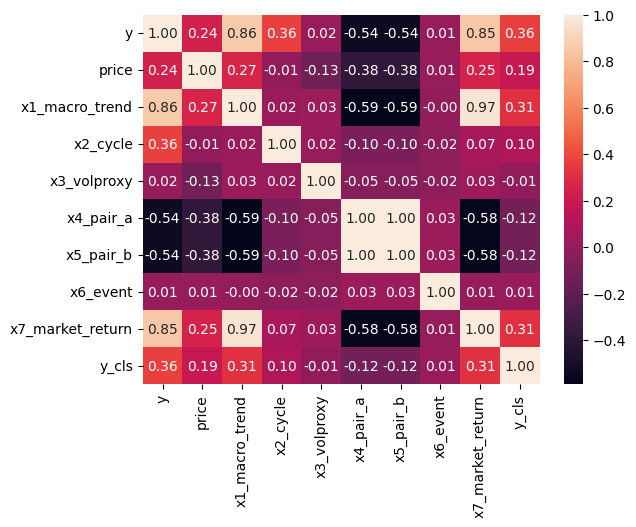

In [4]:
import seaborn as sns

sns.heatmap(df.select_dtypes(np.number).corr(), annot=True, fmt=".2f")

In [12]:
df.shape
df.sort_index().drop_duplicates().shape

(1565, 11)

In [16]:
df.isna().sum(axis=0)
# fill na with mean
df = df.fillna(df.mean(numeric_only=True))

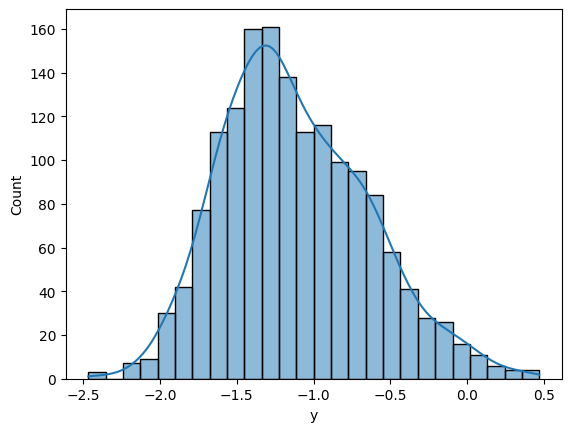

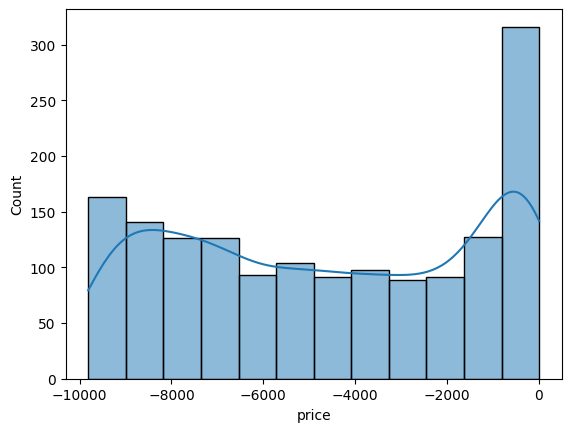

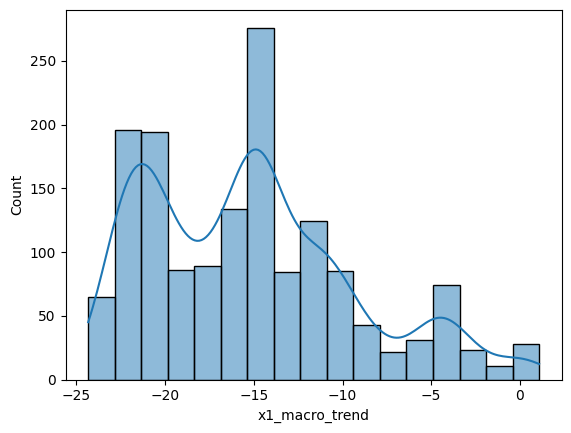

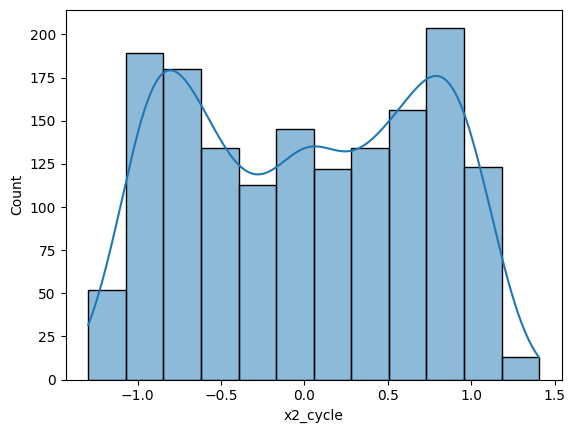

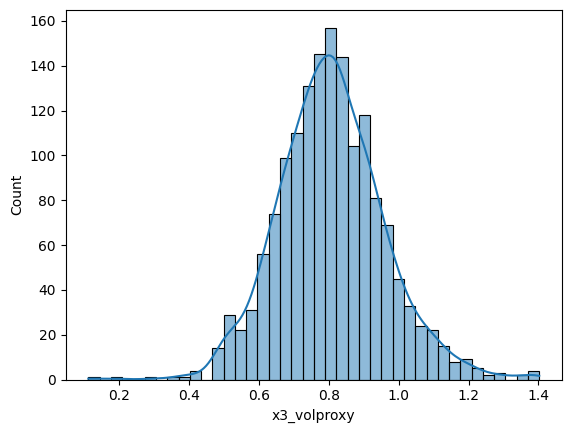

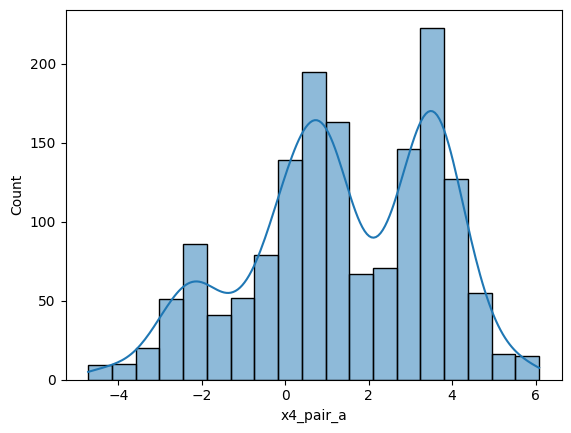

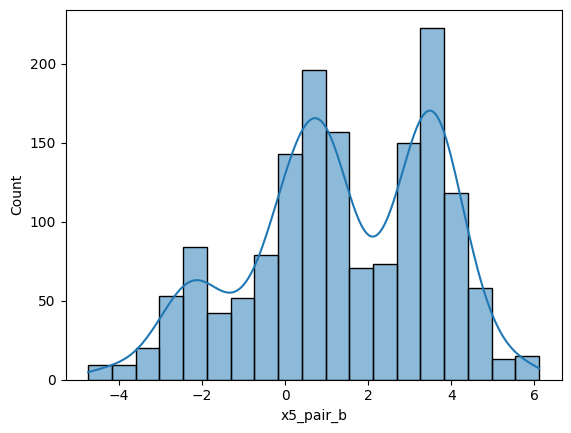

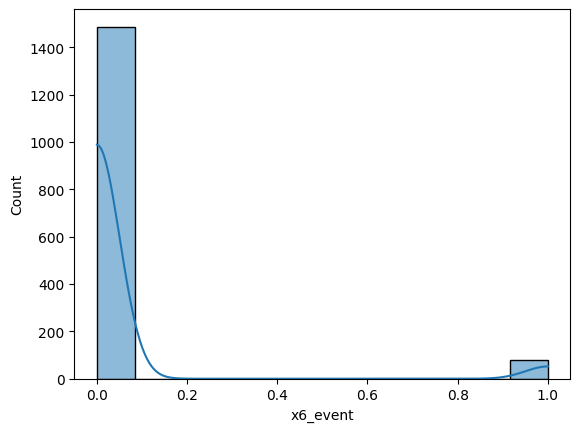

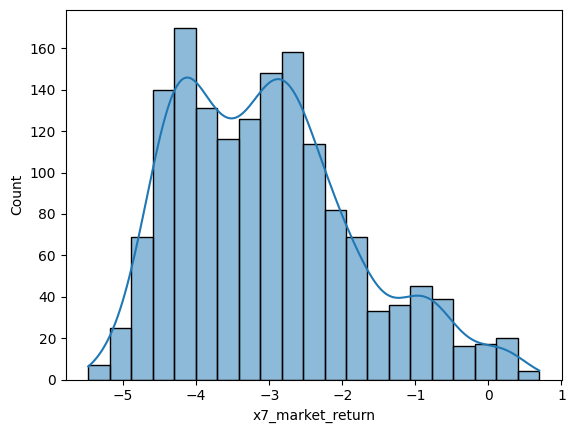

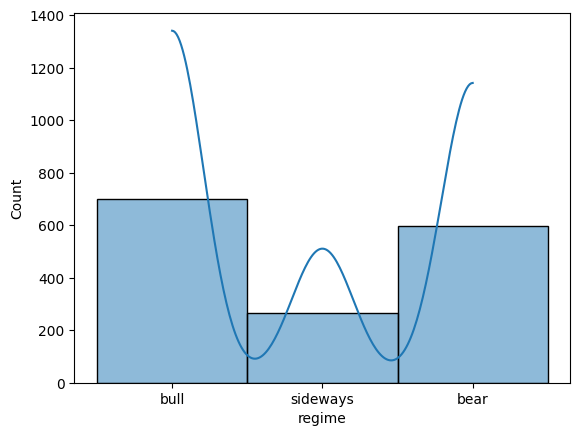

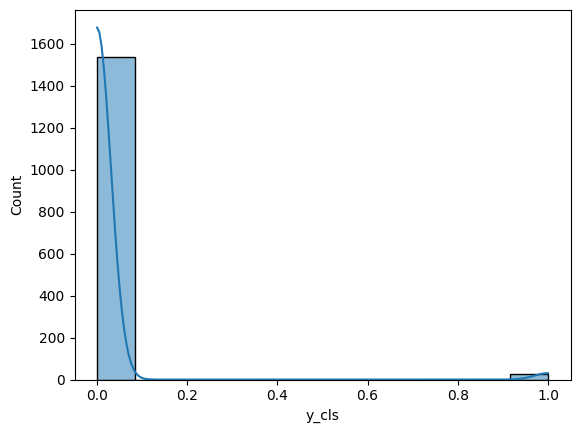

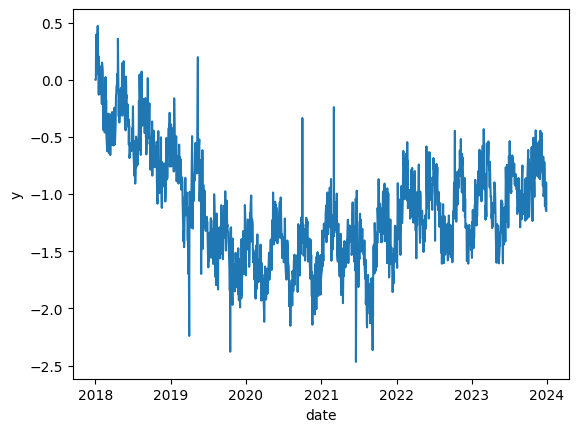

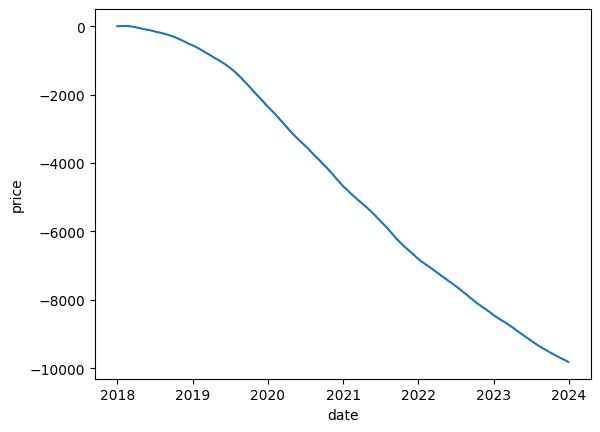

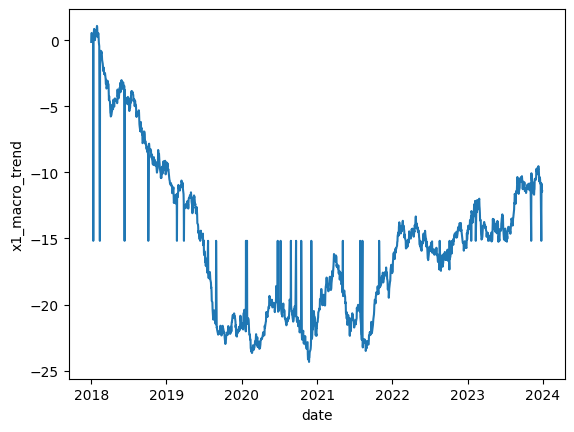

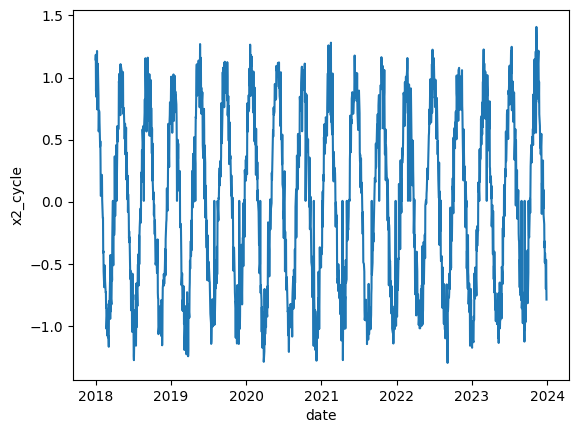

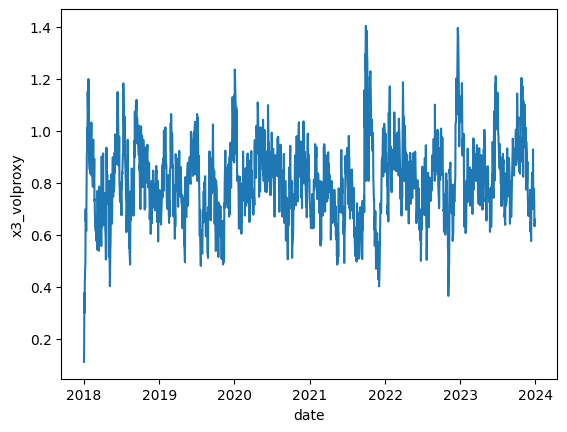

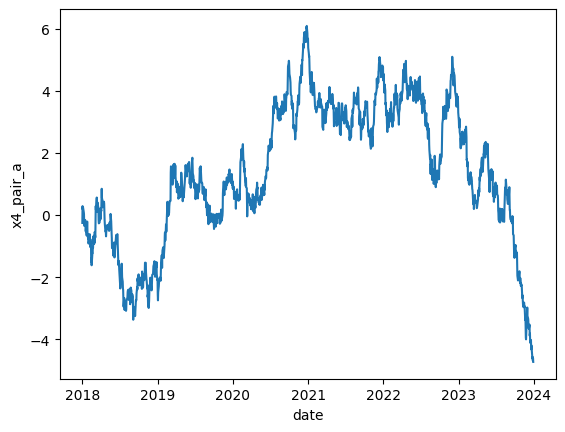

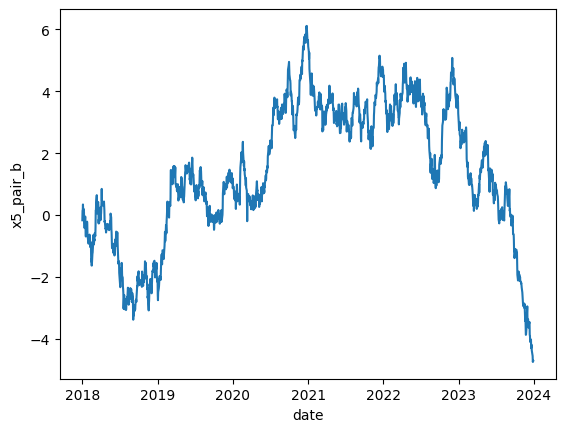

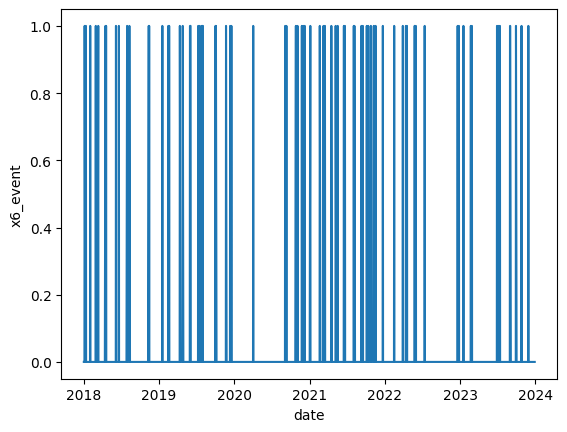

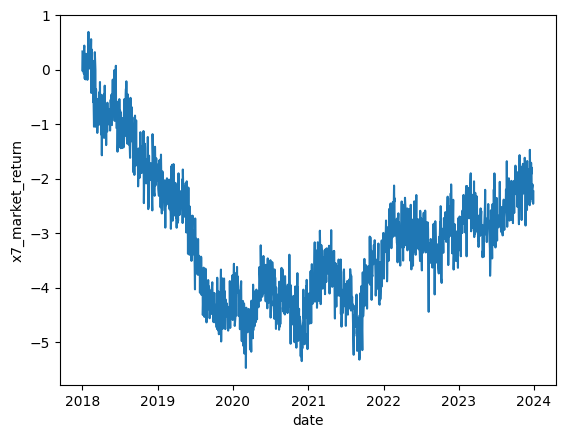

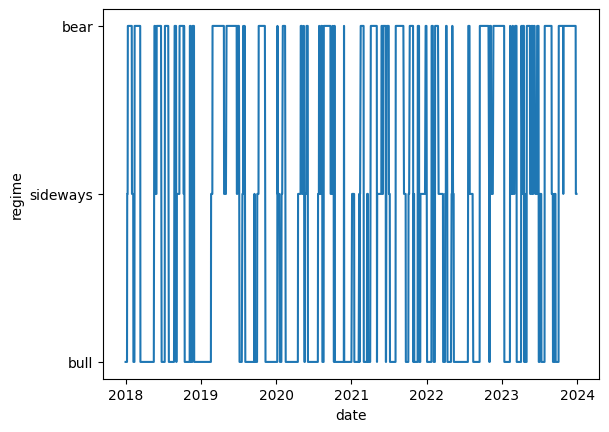

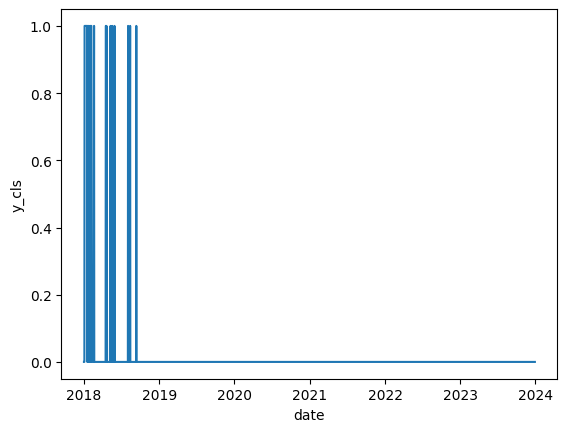

In [17]:
import matplotlib.pyplot as plt

for col in df.columns:
    sns.histplot(df[col], kde=True)
    plt.xlabel(col)
    plt.show()
    
for col in df.columns:
    plt.plot(df[col])
    plt.xlabel("date")
    plt.ylabel(col)
    plt.show()

<Axes: xlabel='date'>

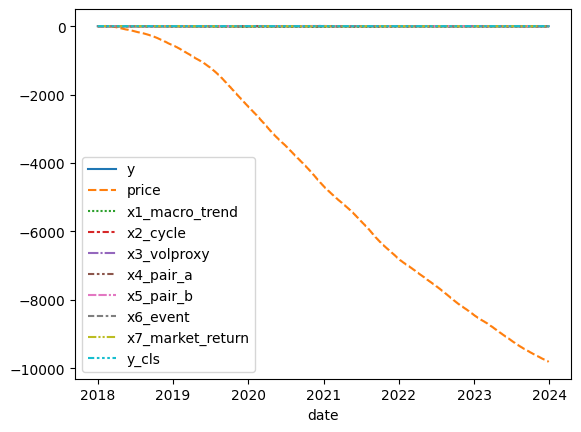

In [18]:
sns.lineplot(data=df)

In [19]:
df.describe()

,y,price,x1_macro_trend,x2_cycle,x3_volproxy,x4_pair_a,x5_pair_b,x6_event,x7_market_return,y_cls
count,1565.000000,1565.000000,1565.000000,1565.000000,1565.000000,1565.000000,1565.000000,1565.000000,1565.000000,1565.000000
mean,-1.120701,-4581.175668,-15.176089,0.007630,0.806764,1.387592,1.387244,0.049840,-3.030216,0.017891
std,0.477682,3271.035796,5.829101,0.703385,0.151895,2.223356,2.222736,0.217684,1.224061,0.132599
min,-2.467314,-9812.204390,-24.340154,-1.296401,0.110822,-4.723649,-4.745572,0.000000,-5.476362,0.000000
25%,-1.467187,-7594.283515,-20.427118,-0.660271,0.708797,-0.020890,-0.028639,0.000000,-4.037881,0.000000
50%,-1.185129,-4663.865930,-15.227304,0.007630,0.806764,1.294828,1.288186,0.000000,-3.132085,0.000000
75%,-0.793300,-1216.058176,-11.637049,0.654157,0.898366,3.356534,3.350799,0.000000,-2.315061,0.000000
max,0.470492,7.474861,1.085615,1.407257,1.402533,6.083780,6.114983,1.000000,0.695907,1.000000


Using Z score: 

y :  5
Using IQR: 

y: (8, 0.5111821086261981)
Using Z score: 

price :  0
Using IQR: 

price: (0, 0.0)
Using Z score: 

x1_macro_trend :  0
Using IQR: 

x1_macro_trend: (0, 0.0)
Using Z score: 

x2_cycle :  0
Using IQR: 

x2_cycle: (0, 0.0)
Using Z score: 

x3_volproxy :  14
Using IQR: 

x3_volproxy: (31, 1.9808306709265175)
Using Z score: 

x4_pair_a :  0
Using IQR: 

x4_pair_a: (0, 0.0)
Using Z score: 

x5_pair_b :  0
Using IQR: 

x5_pair_b: (0, 0.0)
Using Z score: 

x6_event :  78
Using IQR: 

x6_event: (78, 4.984025559105431)
Using Z score: 

x7_market_return :  1
Using IQR: 

x7_market_return: (14, 0.8945686900958467)
Using Z score: 

y_cls :  28
Using IQR: 

y_cls: (28, 1.7891373801916934)


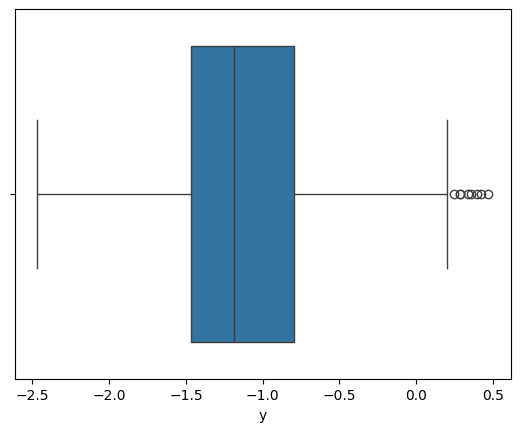

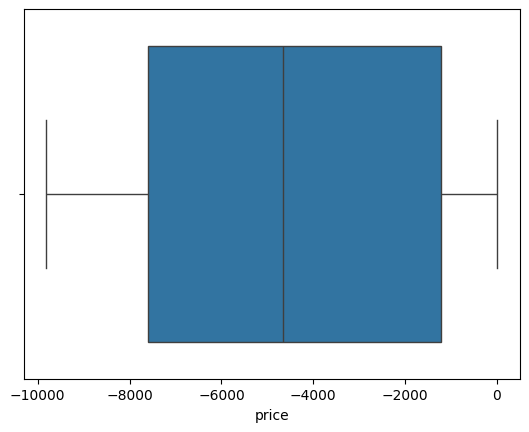

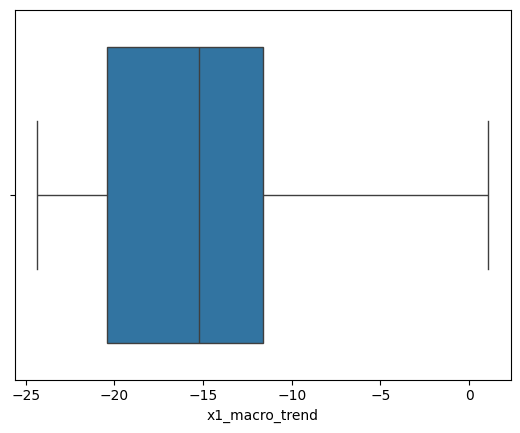

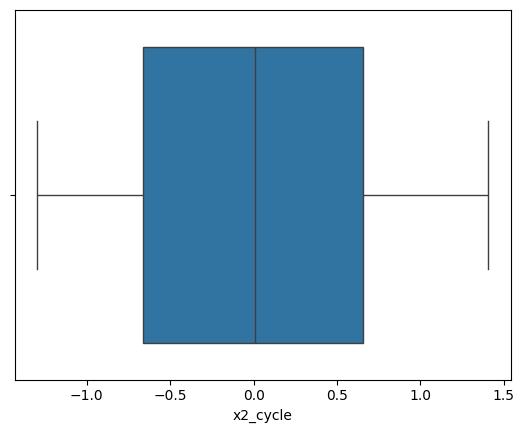

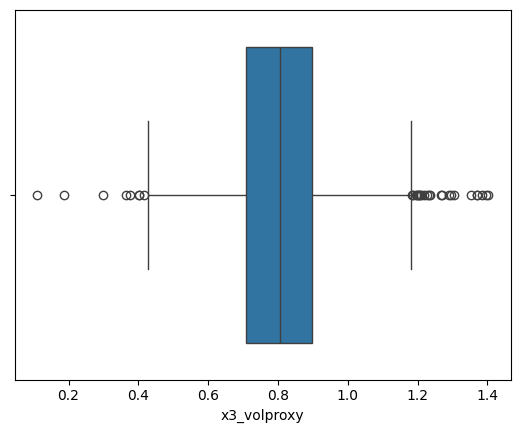

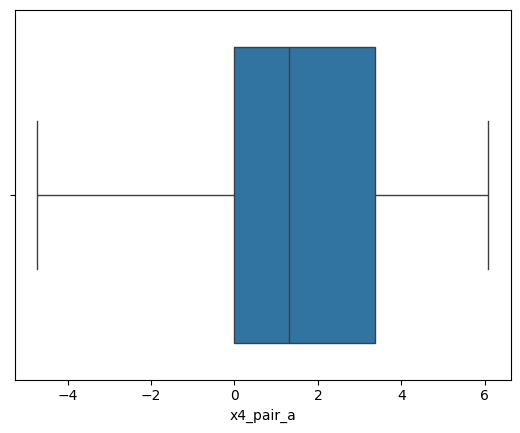

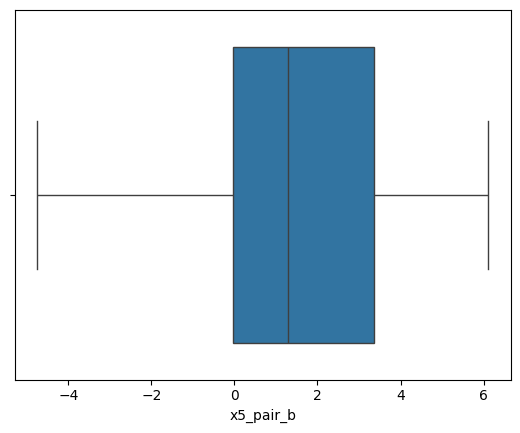

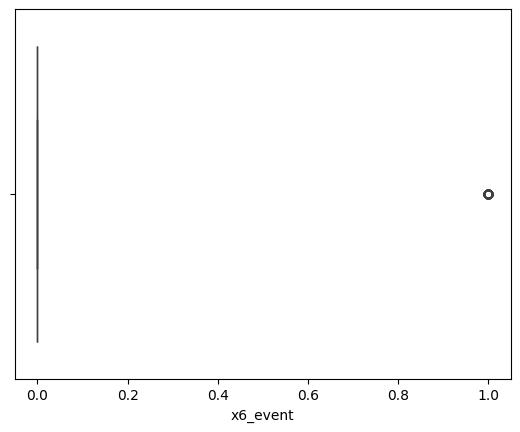

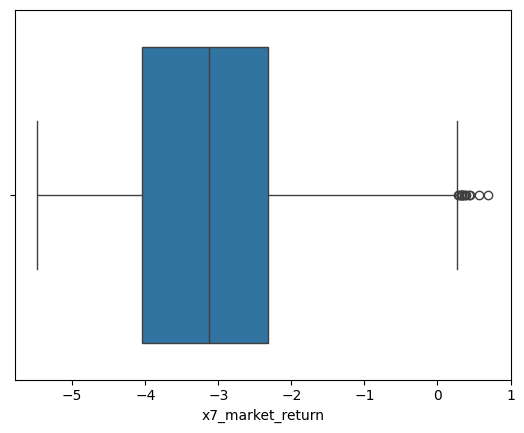

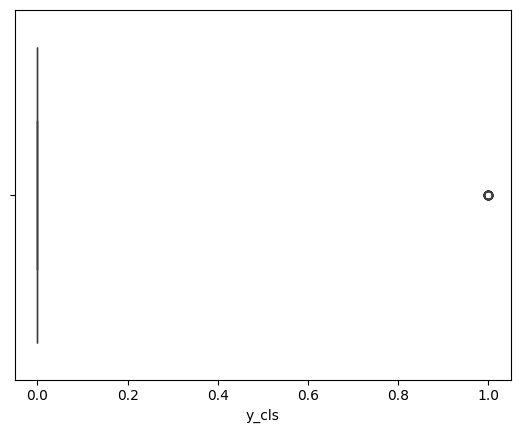

In [22]:
# find the number of outliers in each column using IQR

def count_outliers(series):
    Q1 = series.quantile(0.25)
    Q3 = series.quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = series[(series < lower_bound) | (series > upper_bound)]
    return len(outliers), len(outliers)/len(series) * 100

# do the same but now using z score

for col in df.select_dtypes(np.number).columns:
    m = df[col].mean()
    std = df[col].std()
    out = df[abs(df[col] - m) > 3 * std]
    print("Using Z score: \n")
    print(f"{col} : ", len(out)), len(out)/len(df)
    
    print("Using IQR: \n")
    print(f"{col}: {count_outliers(df[col])}")
    
# plot boxplot for each column
for col in df.select_dtypes(np.number).columns:
    sns.boxplot(x=df[col])
    plt.xlabel(col)
    plt.show()

In [25]:
target = df["y"]
features = df.drop(columns=["y"])
Y = target
X = features

for lag in range(1, 4):
    features[f"y_lag_{lag}"] = target.shift(lag)
    
df = X.join(Y).dropna()
X = df.drop(columns=["y"])
Y = df["y"]

from sklearn.preprocessing import PolynomialFeatures

poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X[X.select_dtypes(np.number).columns])
X_poly_df = pd.DataFrame(X_poly, columns=poly.get_feature_names_out(X.select_dtypes(np.number).columns))
X_poly_df.shape

(1556, 90)

In [26]:
# concatenate X_poly_df with non numeric columns in X
X_final = pd.concat([X_poly_df, X.select_dtypes(exclude=np.number).reset_index(drop=True)], axis=1)
X_final.shape

(1556, 91)

In [27]:
split = int(0.8 * len(X_final))
X_train, X_test = X_final[:split], X_final[split:]
Y_train, Y_test = Y[:split], Y[split:]

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train[X_train.select_dtypes(np.number).columns] = scaler.fit_transform(X_train.select_dtypes(np.number))
X_test[X_test.select_dtypes(np.number).columns] = scaler.transform(X_test.select_dtypes(np.number))

/tmp/ipykernel_11803/3586219840.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_train[X_train.select_dtypes(np.number).columns] = scaler.fit_transform(X_train.select_dtypes(np.number))
/tmp/ipykernel_11803/3586219840.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_test[X_test.select_dtypes(np.number).columns] = scaler.transform(X_test.select_dtypes(np.number))


In [28]:
# one hot encode categorical variables
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
X_train_cat = ohe.fit_transform(X_train.select_dtypes(exclude=np.number))
X_test_cat = ohe.transform(X_test.select_dtypes(exclude=np.number))
X_train_cat.shape, X_test_cat.shape

((1244, 3), (312, 3))

In [29]:
from sklearn.linear_model import Ridge, Lasso, ElasticNetCV

X_train = np.hstack([X_train.select_dtypes(np.number), X_train_cat])
X_test = np.hstack([X_test.select_dtypes(np.number), X_test_cat])
X_train.shape, X_test.shape

((1244, 93), (312, 93))

In [30]:
reg = Ridge()
reg.fit(X_train, Y_train)
reg.predict(X_test)

reg.score(X_test, Y_test)


0.5146615718540735

In [31]:
reg.summary()

AttributeError: 'Ridge' object has no attribute 'summary'